In [55]:
from daq import MyDAQ
import numpy as np
from matplotlib import pyplot as plt
from scipy.signal import welch

# Create MyDAQ instance
daq = MyDAQ()
print(daq)
# Give DAQ a name and samplerate
daq.name = "myDAQ2"
daq.samplerate = 200_000  # Hz

print()
print(daq)

MyDAQ instance
Base name: None
Sample rate: None

MyDAQ instance
Base name: myDAQ2
Sample rate: 200000


In [195]:
'''Read on channel 1 for 2 seconds, then on channel 2 for 1 second (succesively)'''

print('Press enter to start reading')
input("Press enter to start reading back to back")
print('Reading...')
# Read on channel 1 for 2 seconds, then on channel 2 for 1 second (succesively)
read_duration = 10  # seconds
TimeArray = daq.getTimeArray(read_duration, daq.samplerate)
data1 = daq.read(read_duration, "AI0") 

experiment_number = 4
#save_name = f'Data_2/measurement{experiment_number}'
save_name = f'Data_2/short'
np.savez(f"{save_name}.npz", data1=data1)




Press enter to start reading
Reading...


In [196]:
'''Loading data for plotting and analysis'''

experiment_loading_number = 4
data1 = np.load(f'Data_2/measurement{experiment_loading_number}.npz')['data1']
noise_data = np.load(f'Data_2/short.npz')['data1']

Mean square voltage in the band 1000 Hz to 100000 Hz: 2.096385e-03 V^2
Root mean square voltage in the band 1000 Hz to 100000 Hz: 4.578630e+01 mV


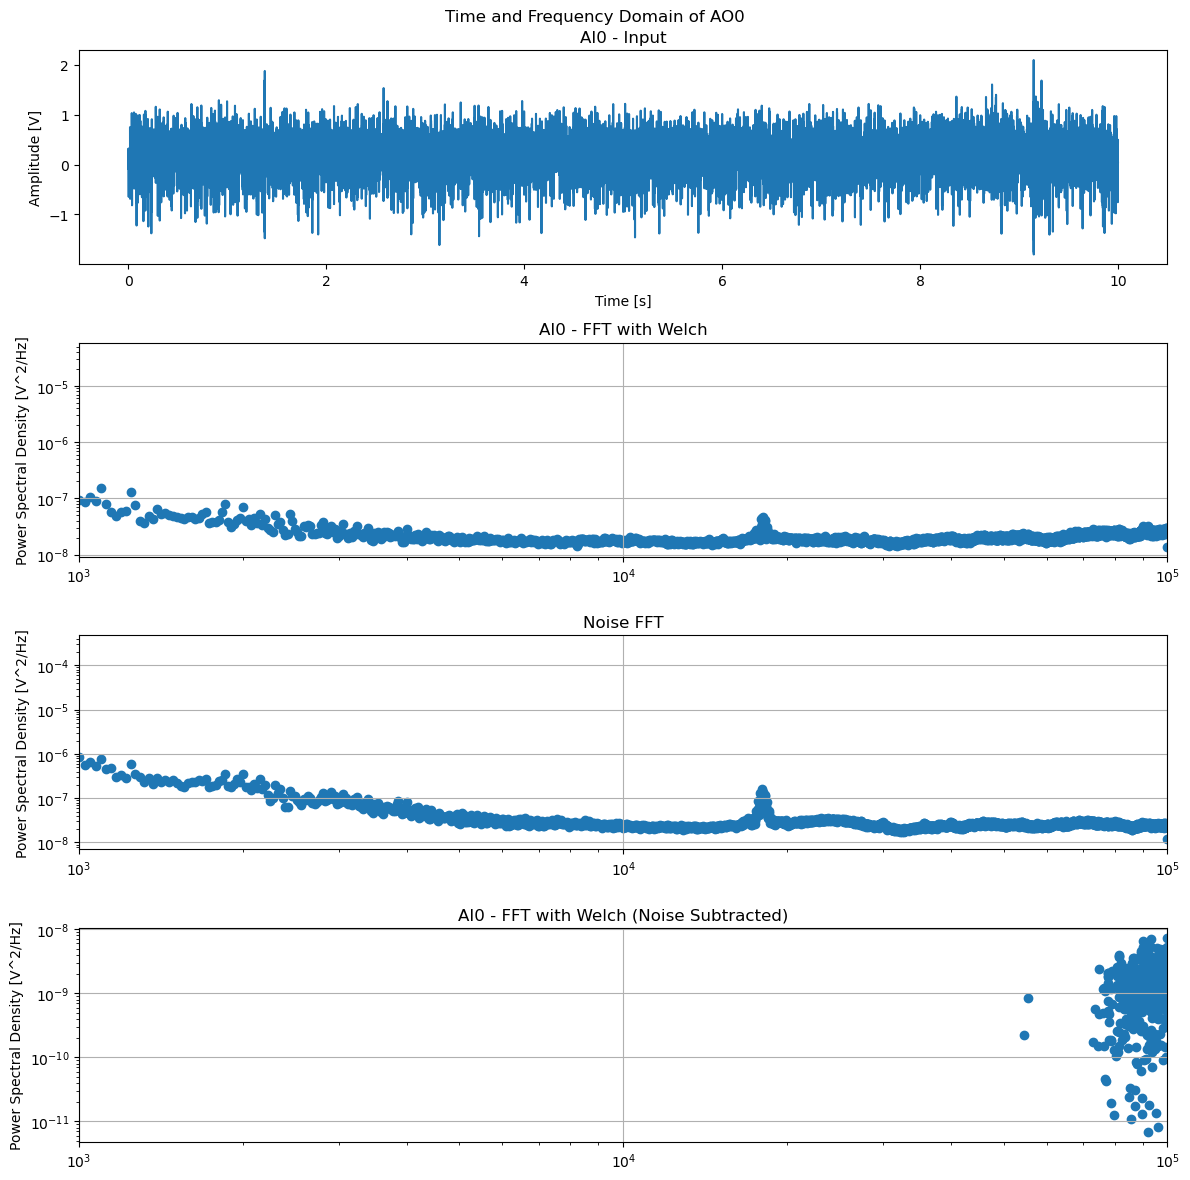

In [199]:

fig, axes = plt.subplots(4, 1, figsize=(12, 12))



plt.suptitle("Time and Frequency Domain of AO0")

axes[0].plot(TimeArray, data1)
axes[0].set_title("AI0 - Input")
axes[0].set_ylabel("Amplitude [V]")
axes[0].set_xlabel("Time [s]")

fs = daq.samplerate
nperseg = 8192

f_in, P_in = welch(data1, fs=fs, nperseg=nperseg, window='hann')
axes[1].scatter(f_in, P_in)

# Do welch with noise data and subtract the noise from the signal
f_noise, P_noise = welch(noise_data, fs=fs, nperseg=nperseg, window='hann')

#slice the frewuencies to start from 1 KHz and end at 100 kHz
axes[1].set_xlim(1000, 100000)
# make X axis logarithmic 
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_ylabel("Power Spectral Density [V^2/Hz]")
axes[1].set_title("AI0 - FFT with Welch")
axes[1].grid(True)

axes[2].scatter(f_in, P_noise)
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].set_ylabel("Power Spectral Density [V^2/Hz]")
axes[2].set_xlim(1000, 100000)
axes[2].set_title("Noise FFT")
axes[2].grid(True)

axes[3].scatter(f_in, P_in - P_noise)
axes[3].set_xscale('log')
axes[3].set_yscale('log')
axes[3].set_ylabel("Power Spectral Density [V^2/Hz]")
axes[3].set_xlim(1000, 100000)
axes[3].set_title("AI0 - FFT with Welch (Noise Subtracted)")
axes[3].grid(True)

#Integrate the power spectral density to get Mean square voltage in a frequency band from 1 KHz to 100 kHz
freq_band = (1000, 100000)
band_mask = (f_in >= freq_band[0]) & (f_in <= freq_band[1])
mean_square_voltage = np.trapz(P_in[band_mask], f_in[band_mask])
print(f"Mean square voltage in the band {freq_band[0]} Hz to {freq_band[1]} Hz: {mean_square_voltage:.6e} V^2")
root_mean_square_voltage = np.sqrt(mean_square_voltage)
print(f"Root mean square voltage in the band {freq_band[0]} Hz to {freq_band[1]} Hz: {(root_mean_square_voltage*1000):.6e} mV")

plt.tight_layout()
plt.show()

1.4947377368555962e-08
9.339192290050073e-08
5.574373171894841e-08
2.2794988170170275e-08
4.1968431538100335e-08
2.156451686389552e-08


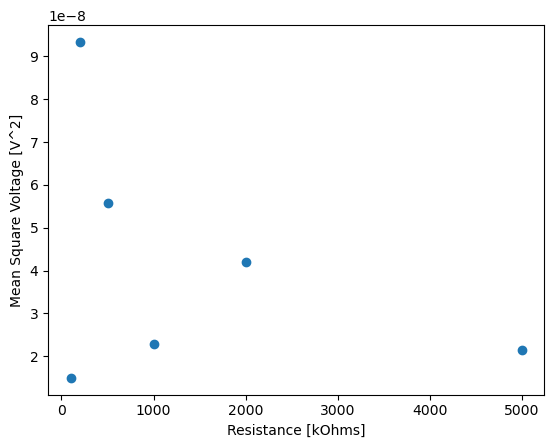

1.3504366317019505e-12
1.63944e-15


In [ ]:
# Calculate the MEAN square voltage for all measurements in the Data folder and plot them as a bar graph. measurement1, measurement2, measurement3, measurement4, measurement5
mean_square_voltages = []
for i in range(1, 7):
    data = np.load(f'Data/measurement{i}.npz')['data1']
    noise_data = np.load(f'Data/noise{i}.npz')['data1']
    f, P = welch(data, fs=fs, nperseg=nperseg, window='hann')
    band_mask = (f >= freq_band[0]) & (f <= freq_band[1])
    P -= welch(noise_data, fs=fs, nperseg=nperseg, window='hann')[1]
    # Transfrom to the real signal by dividing by the gain of the amplifier (1000)
    P = P / (1000**2)
    mean_square_voltage = np.trapz(P[band_mask], f[band_mask])
    print(mean_square_voltage)
    mean_square_voltages.append(mean_square_voltage)

resistor_values = [100, 200, 500, 1000, 2000, 5000]  # kOhms
plt.scatter(resistor_values, mean_square_voltages)






plt.xlabel("Resistance [kOhms]")
plt.ylabel("Mean Square Voltage [V^2]")
plt.show()
diff = (mean_square_voltages[5] - mean_square_voltages[0])/(resistor_values[5]  - resistor_values[0])
print(diff)
theoretial_slope = 4 * 1.38e-23 * 300m  # 4 * k_B * T

print(4 * 1.38e-23 * 300* 99000 )  # 4 * k_B * T * R

Mean gain in 1000–95000 Hz band: 37.5
Gain variation: 402.24%  (acceptance criterion: < 5%)


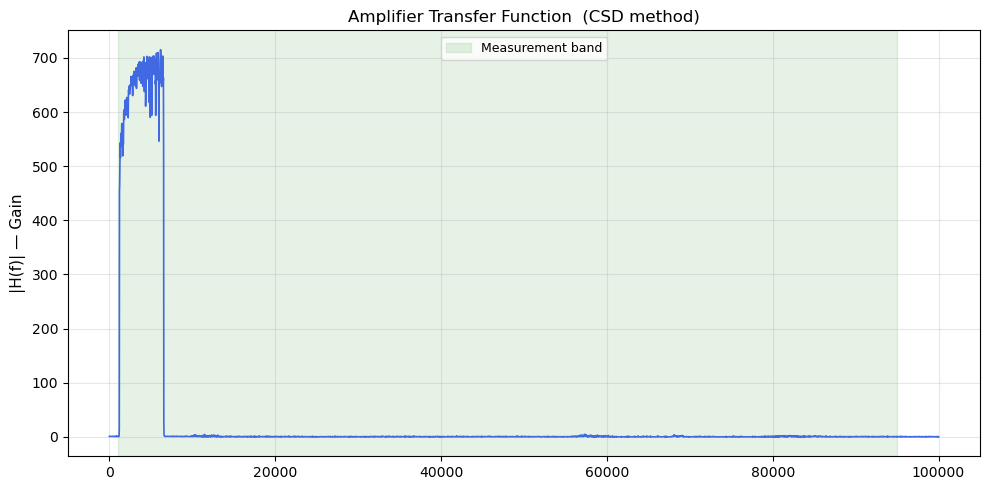

In [40]:
from scipy.signal import csd, welch

print('Press enter to start reading')
input("Press enter to start reading back to back")
print('Reading...')
# Read on channel 1 for 2 seconds, then on channel 2 for 1 second (succesively)
read_duration = 35  # seconds
TimeArray = daq.getTimeArray(read_duration, daq.samplerate)
data1, data2 = daq.read(read_duration, "AI0", "AI1") 

gain_experiment_number = 1
save_name = f'Data/gain{gain_experiment_number}'
np.savez(f"{save_name}.npz", data1=data1, data2=data2)


TimeArray = daq.getTimeArray(read_duration, daq.samplerate)
fs      = daq.samplerate
nperseg = 8192  # adjust for frequency resolution vs smoothness

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
plt.suptitle("Time and Frequency Domain of Input and Output Signals")

# ── Time domain ───────────────────────────────────────────────────────────
axes[0, 0].scatter(TimeArray, data1)
axes[0, 0].set_title("AI0 — Input")
# limit X axis to 10 cycles of 35 kHz
axes[0, 0].set_ylabel("Amplitude [V]")
axes[0, 0].set_xlabel("Time [s]")
 
axes[0, 1].plot(TimeArray, data2)
axes[0, 1].set_title("AI1 — Output")
axes[0, 1].set_ylabel("Amplitude [V]")
axes[0, 1].set_xlabel("Time [s]")

# ── Frequency domain: PSD of each channel ────────────────────────────────
f_in,  P_in  = welch(data1, fs=fs, nperseg=nperseg, window='hann')
f_out, P_out = welch(data2, fs=fs, nperseg=nperseg, window='hann')

axes[1, 0].semilogy(f_in,  P_in)
axes[1, 0].set_title("AI0 — PSD")
axes[1, 0].set_ylabel("PSD [V²/Hz]")
axes[1, 0].set_xlabel("Frequency [Hz]")
axes[1, 0].grid(True, which='both', alpha=0.3)

axes[1, 1].semilogy(f_out, P_out)
axes[1, 1].set_title("AI1 — PSD")
axes[1, 1].set_ylabel("PSD [V²/Hz]")
axes[1, 1].set_xlabel("Frequency [Hz]")
axes[1, 1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

# ── Transfer function via CSD method ─────────────────────────────────────
# H(f) = S_12(f) / S_11(f)
# S_12 = cross-PSD between input and output
# S_11 = PSD of input
f_h, S12 = csd(data1, data2, fs=fs, nperseg=nperseg, window='hann')
f_h, S11 = welch(data1,       fs=fs, nperseg=nperseg, window='hann')

gain  = np.abs(S12 / S11)


# ── Summary over measurement band ────────────────────────────────────────
f_low, f_high = 1000, 95000
mask = (f_h >= f_low) & (f_h <= f_high)

gain_mean = np.mean(gain[mask])
gain_var  = np.std(gain[mask]) / gain_mean * 100

print(f"Mean gain in {f_low}–{f_high} Hz band: {gain_mean:.1f}")
print(f"Gain variation: {gain_var:.2f}%  (acceptance criterion: < 5%)")

# ── Plot transfer function ────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 5))

plt.plot(f_h, gain, lw=1.2, color='royalblue')
plt.axvspan(f_low, f_high, alpha=0.1, color='green', label='Measurement band')
plt.ylabel("|H(f)| — Gain", fontsize=11)
plt.title("Amplifier Transfer Function  (CSD method)", fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save the gain data for later use
np.savez("gain_data.npz", f_h=f_h, gain=gain)

# 

In [ ]:
# Repeat transfer function measurement 5 times to assess variability and create master gain curve
all_gains = []
read_duration = 30  # seconds per measurement
for i in range(5):
    print(f"Measurement {i+1}/5: Press enter to start")
    input()
    data1, data2 = daq.read(read_duration, "AI0", "AI1") 
    f_h, S12 = csd(data1, data2, fs=fs, nperseg=nperseg, window='hann')
    f_h, S11 = welch(data1,       fs=fs, nperseg=nperseg, window='hann')
    gain  = np.abs(S12 / S11)
    all_gains.append(gain)

# Average gain across measurements
master_gain = np.mean(all_gains, axis=0)
plt.figure(figsize=(10, 5))
plt.plot(f_h, master_gain, lw=1.2, color='darkorange', label='Master Gain Curve')
plt.axvspan(f_low, f_high, alpha=0.1, color='green', label='Measurement band')
plt.ylabel("|H(f)| — Gain", fontsize=11)
plt.title("Master Amplifier Transfer Function  (CSD method)", fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Save the master gain curve for later use
np.savez("master_gain_data.npz", f_h=f_h, master_gain=master_gain)

In [ ]:
# Load the Master gain curve
data = np.load("master_gain_data.npz")  
f_h = data['f_h']
master_gain = data['master_gain']

